In [130]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.ar_model import AutoReg
from sklearn.metrics import mean_squared_error

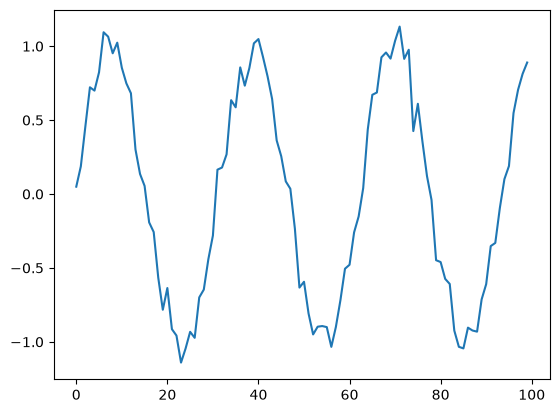

In [131]:
np.random.seed(42)

tamanho_dados = 100
X_dados = np.arange(0, 100)
dados_estacionarios = np.sin(np.linspace(0, 20, tamanho_dados)) + np.random.normal(0, 0.1, tamanho_dados)
plt.plot(dados_estacionarios)
plt.show()

In [132]:
# SEPARA OS DADOS EM TREINO E TESTE PARA TESTAR A AUTO REGRESSÃO -----------------------------
ponto_corte = 90
X_treino = X_dados[:ponto_corte]
dados_treino = dados_estacionarios[:ponto_corte]

X_teste = X_dados[ponto_corte:]
dados_teste = dados_estacionarios[ponto_corte:]

LAG: 15, AIC: -114.36, ERRO: 0.0650


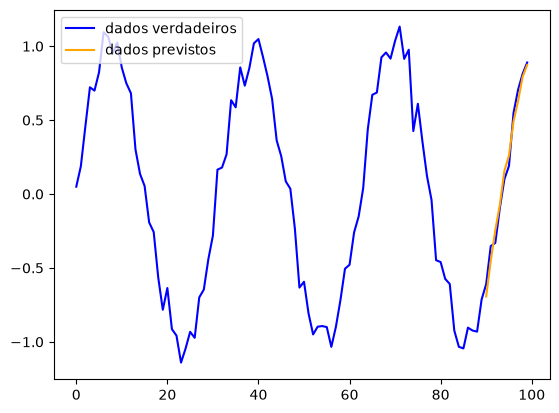

In [133]:
# executa a auto regressão com lag=15
lag = 15
modelo = AutoReg(dados_treino, lags=lag)
resultado = modelo.fit()

# executa a previsao e calcula o erro delas
previsoes = resultado.predict(start=len(X_treino), end=len(X_treino)+len(X_teste)-1)
MSE = mean_squared_error(dados_teste, previsoes)
RMSE = np.sqrt(MSE)

print(f'LAG: {lag}, AIC: {resultado.aic:.2f}, ERRO: {RMSE:.4f}')

plt.plot(X_dados, dados_estacionarios, color='blue', label='dados verdadeiros')
plt.plot(X_teste, previsoes, color='orange', label='dados previstos')
plt.legend(loc="upper left") 
plt.show()

In [134]:
# encontrando o melhor lag
melhor_lag_segundo_aic = 0
menor_aic = 999_999_999
erro_do_menor_aic = 0

melhor_lag_segundo_erro = 0
menor_erro = 999_999_999
aic_do_menor_erro = 0

for i in range(1, len(X_treino)//2-1):
    modelo = AutoReg(dados_treino, i)
    result = modelo.fit()
    aic = result.aic
    dados_pred = result.predict(start=len(dados_treino), end=len(dados_treino)+len(dados_teste)-1)
    MSE = mean_squared_error(dados_teste, dados_pred)
    RMSE = np.sqrt(MSE)
    if(aic < menor_aic):
        menor_aic = aic
        melhor_lag_segundo_aic = i
        erro_do_menor_aic = RMSE
    if(RMSE < menor_erro):
        menor_erro = RMSE
        melhor_lag_segundo_erro = i
        aic_do_menor_erro = aic
    print(f'I = {i}, AIC = {aic:.2f} ERRO: {RMSE:.4f}')

print(f'MELHOR LAG PELO AIC FOI {melhor_lag_segundo_aic}. AIC = {menor_aic}. ERRO = {erro_do_menor_aic}')
print(f'MELHOR LAG PELO ERRO FOI {melhor_lag_segundo_erro}. ERRO = {menor_erro}. AIC = {aic_do_menor_erro}')

I = 1, AIC = -34.46 ERRO: 0.9566
I = 2, AIC = -40.27 ERRO: 0.7958
I = 3, AIC = -60.08 ERRO: 0.4989
I = 4, AIC = -77.63 ERRO: 0.3137
I = 5, AIC = -81.23 ERRO: 0.1804
I = 6, AIC = -97.48 ERRO: 0.0752
I = 7, AIC = -105.96 ERRO: 0.0795
I = 8, AIC = -113.64 ERRO: 0.0644
I = 9, AIC = -113.14 ERRO: 0.0625
I = 10, AIC = -117.61 ERRO: 0.0652
I = 11, AIC = -112.95 ERRO: 0.0652
I = 12, AIC = -113.08 ERRO: 0.0558
I = 13, AIC = -111.86 ERRO: 0.0543
I = 14, AIC = -109.27 ERRO: 0.0544
I = 15, AIC = -114.36 ERRO: 0.0650
I = 16, AIC = -113.65 ERRO: 0.0674
I = 17, AIC = -109.59 ERRO: 0.0633
I = 18, AIC = -105.07 ERRO: 0.0659
I = 19, AIC = -100.45 ERRO: 0.0646
I = 20, AIC = -96.02 ERRO: 0.0688
I = 21, AIC = -95.99 ERRO: 0.0685
I = 22, AIC = -91.78 ERRO: 0.0742
I = 23, AIC = -87.51 ERRO: 0.0743
I = 24, AIC = -84.68 ERRO: 0.0732
I = 25, AIC = -82.30 ERRO: 0.0780
I = 26, AIC = -77.96 ERRO: 0.0872
I = 27, AIC = -78.09 ERRO: 0.0993
I = 28, AIC = -74.18 ERRO: 0.0984
I = 29, AIC = -71.75 ERRO: 0.1008
I = 30, AI

LAG: 10, AIC: -117.61, ERRO: 0.0652


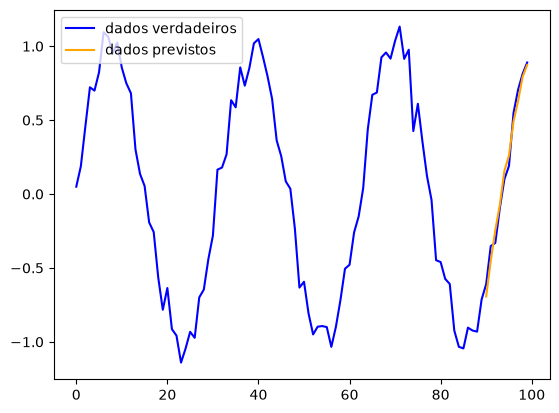

In [135]:
# ANALISE DA REGRESSAO COM O LAG DADO PELO MENOR AIC
modelo = AutoReg(dados_treino, melhor_lag_segundo_aic)
resultado = modelo.fit()
dados_pred = resultado.predict(start=len(dados_treino), end=len(dados_treino)+len(dados_teste)-1)

print(f'LAG: {melhor_lag_segundo_aic}, AIC: {resultado.aic:.2f}, ERRO: {erro_do_menor_aic:.4f}')

plt.plot(X_dados, dados_estacionarios, color='blue', label='dados verdadeiros')
plt.plot(X_teste, previsoes, color='orange', label='dados previstos')
plt.legend(loc="upper left") 
plt.show()

LAG: 13, AIC: -111.86, ERRO: 0.0543


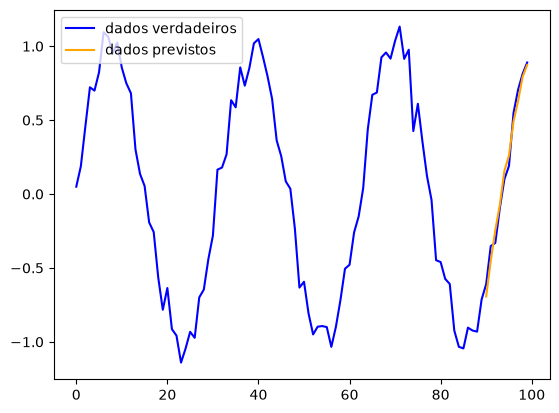

In [136]:
# ANALISE DA REGRESSAO COM O LAG DADO PELO MENOR ERRO
modelo = AutoReg(dados_treino, melhor_lag_segundo_erro)
resultado = modelo.fit()
dados_pred = resultado.predict(start=len(dados_treino), end=len(dados_treino)+len(dados_teste)-1)

print(f'LAG: {melhor_lag_segundo_erro}, AIC: {resultado.aic:.2f}, ERRO: {menor_erro:.4f}')

plt.plot(X_dados, dados_estacionarios, color='blue', label='dados verdadeiros')
plt.plot(X_teste, previsoes, color='orange', label='dados previstos')
plt.legend(loc="upper left") 
plt.show()